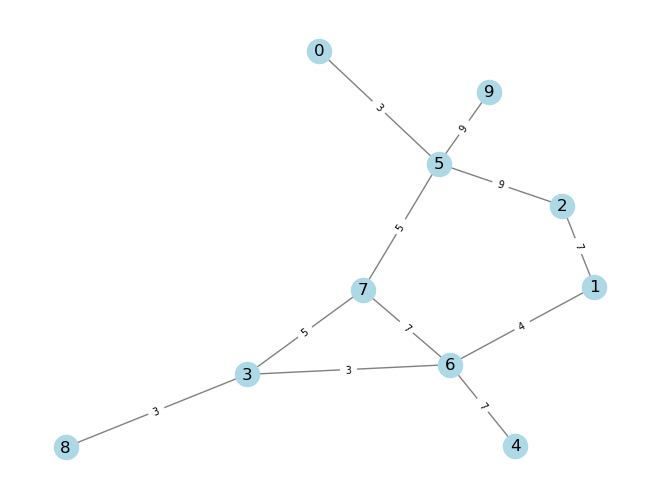

In [14]:
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
from Graphs.plot_weights_graph import PlotWeightsGraph as PWG

matrix = np.loadtxt('Graphs/test_graph_with_weights.txt', dtype=int)

G = nx.from_numpy_array(matrix)


simpleTestEdges = [(0, 1, 2), (0, 2, 3), (1, 2, 1,), (2, 4, 5), (2, 3, 1)]
simpleTestGraph = nx.Graph()
simpleTestGraph.add_weighted_edges_from(simpleTestEdges)
#G = simpleTestGraph

plt.show(PWG(G))

In [15]:
class UnionFind:
    def __init__(self, vertices):
        # Initially, every node is its own parent (its own separate tree)
        self.parent = {v: v for v in vertices}
        self.rank = {v: 0 for v in vertices}

    def find(self, item):
        # Find the root of the tree this item belongs to
        if self.parent[item] == item:
            return item
        # Path compression (optimizes future lookups)
        self.parent[item] = self.find(self.parent[item])
        return self.parent[item]

    def union(self, set1, set2):
        # Join two separate trees together
        root1 = self.find(set1)
        root2 = self.find(set2)

        if root1 != root2:
            # Attach the smaller tree under the root of the larger tree
            if self.rank[root1] > self.rank[root2]:
                self.parent[root2] = root1
            elif self.rank[root1] < self.rank[root2]:
                self.parent[root1] = root2
            else:
                self.parent[root2] = root1
                self.rank[root1] += 1
            return True # Successfully joined
        return False # They were already in the same tree!

In [16]:
def count_total_weight(graph):
    total_weight = 0
    for u, v, data in graph.edges(data=True):
        total_weight += data.get('weight', 0)
    return total_weight

print("Total weight of the graph:", count_total_weight(G))

Total weight of the graph: 62


In [17]:
edge_sets = [(u, v, data['weight']) for u, v, data in G.edges(data=True)]
sorted_edge_sets = sorted(edge_sets, key=lambda x: x[2])

vertices = set()
for u, v, weight in sorted_edge_sets:
    vertices.add(u)
    vertices.add(v)

uf = UnionFind(vertices)

MST_edges = []

for u, v, weight in sorted_edge_sets:
    # uf.union returns True if they are in different sets, False if they form a cycle
    if uf.union(u, v):
        MST_edges.append((u, v, weight))

print("Edge sets with weights:", sorted_edge_sets)
print("MST edges:", MST_edges)

Edge sets with weights: [(0, 5, 3), (3, 6, 3), (3, 8, 3), (1, 6, 4), (3, 7, 5), (5, 7, 5), (1, 2, 7), (4, 6, 7), (6, 7, 7), (2, 5, 9), (5, 9, 9)]
MST edges: [(0, 5, 3), (3, 6, 3), (3, 8, 3), (1, 6, 4), (3, 7, 5), (5, 7, 5), (1, 2, 7), (4, 6, 7), (5, 9, 9)]


MST Adjacency Matrix:
 [[0 0 0 0 0 3 0 0 0 0]
 [0 0 7 0 0 0 4 0 0 0]
 [0 7 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 3 5 3 0]
 [0 0 0 0 0 0 7 0 0 0]
 [3 0 0 0 0 0 0 5 0 9]
 [0 4 0 3 7 0 0 0 0 0]
 [0 0 0 5 0 5 0 0 0 0]
 [0 0 0 3 0 0 0 0 0 0]
 [0 0 0 0 0 9 0 0 0 0]]


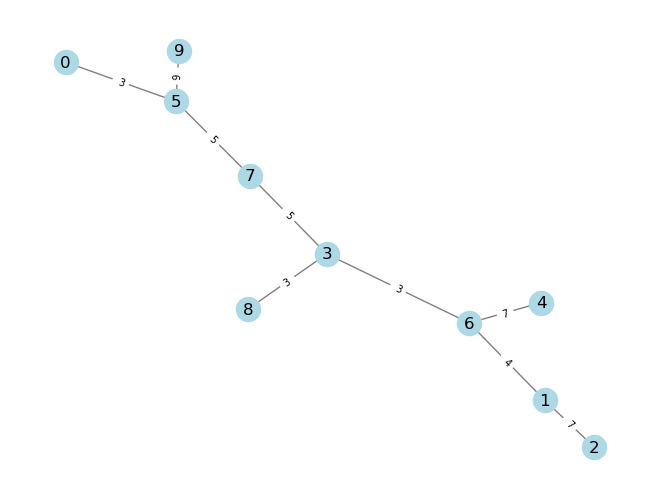

Total weight of MST: 46


In [18]:
def edges_to_matrix(edge_list, num_nodes=None):
    if num_nodes is None:
        num_nodes = max(max(u, v) for u, v, w in edge_list) + 1

    matrix = np.zeros((num_nodes, num_nodes), dtype=int)

    for u, v, weight in edge_list:
        matrix[u][v] = weight
        matrix[v][u] = weight  

    return matrix


MST_matrix = edges_to_matrix(MST_edges)
print("MST Adjacency Matrix:\n", MST_matrix)
PWG(nx.from_numpy_array(MST_matrix))

print("Total weight of MST:", count_total_weight(nx.from_numpy_array(MST_matrix)))